Lex Albrandt  
SYSC410  
Final Project  

In [1]:
# Imports
from math import dist

from matplotlib import axis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

In [2]:
# Load data
file_path = "/home/lexlexpdx/Desktop/valinor/school/SYSC410/final_project/database.csv"
earthquakes_df = pd.read_csv(file_path)

# Check data for cleaning
print(earthquakes_df.info())

# Check columns with null values
print(earthquakes_df.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [3]:
# Drop columns with large amounts of null values
# Also drop RMS column, not useful in this context
drop_columns = [
    "Depth Error",
    "Depth Seismic Stations",
    "Magnitude Error",
    "Magnitude Seismic Stations",
    "Azimuthal Gap",
    "Horizontal Distance",
    "Horizontal Error",
    "Root Mean Square",
    "ID"
]

earthquakes_df_cleaned = earthquakes_df.copy()
earthquakes_df_cleaned = earthquakes_df.drop(columns=drop_columns)
earthquakes_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              23412 non-null  object 
 1   Time              23412 non-null  object 
 2   Latitude          23412 non-null  float64
 3   Longitude         23412 non-null  float64
 4   Type              23412 non-null  object 
 5   Depth             23412 non-null  float64
 6   Magnitude         23412 non-null  float64
 7   Magnitude Type    23409 non-null  object 
 8   Source            23412 non-null  object 
 9   Location Source   23412 non-null  object 
 10  Magnitude Source  23412 non-null  object 
 11  Status            23412 non-null  object 
dtypes: float64(4), object(8)
memory usage: 2.1+ MB


In [4]:
# Fill null values
earthquakes_df_cleaned["Magnitude Type"] = (earthquakes_df_cleaned["Magnitude Type"]
                                            .fillna("Unknown"))
earthquakes_df_cleaned.info()
earthquakes_df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              23412 non-null  object 
 1   Time              23412 non-null  object 
 2   Latitude          23412 non-null  float64
 3   Longitude         23412 non-null  float64
 4   Type              23412 non-null  object 
 5   Depth             23412 non-null  float64
 6   Magnitude         23412 non-null  float64
 7   Magnitude Type    23412 non-null  object 
 8   Source            23412 non-null  object 
 9   Location Source   23412 non-null  object 
 10  Magnitude Source  23412 non-null  object 
 11  Status            23412 non-null  object 
dtypes: float64(4), object(8)
memory usage: 2.1+ MB


,Date,Time,Latitude,Longitude,Type,Depth,Magnitude,Magnitude Type,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,6.0,MW,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,5.8,MW,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,6.2,MW,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,5.8,MW,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,5.8,MW,ISCGEM,ISCGEM,ISCGEM,Automatic


In [5]:
# Convert date column to a datetime type
# This also coerces any values that don't match the format into NaT (null)
earthquakes_df_cleaned["Date"] = pd.to_datetime(
    earthquakes_df_cleaned["Date"],
    format="%m/%d/%Y",
    errors="coerce"
)
earthquakes_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              23409 non-null  datetime64[ns]
 1   Time              23412 non-null  object        
 2   Latitude          23412 non-null  float64       
 3   Longitude         23412 non-null  float64       
 4   Type              23412 non-null  object        
 5   Depth             23412 non-null  float64       
 6   Magnitude         23412 non-null  float64       
 7   Magnitude Type    23412 non-null  object        
 8   Source            23412 non-null  object        
 9   Location Source   23412 non-null  object        
 10  Magnitude Source  23412 non-null  object        
 11  Status            23412 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.1+ MB


In [6]:
# 3 Rows have invalid dates, we will remove those
earthquakes_df_cleaned.dropna(subset=["Date"], inplace=True)
earthquakes_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23409 entries, 0 to 23411
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              23409 non-null  datetime64[ns]
 1   Time              23409 non-null  object        
 2   Latitude          23409 non-null  float64       
 3   Longitude         23409 non-null  float64       
 4   Type              23409 non-null  object        
 5   Depth             23409 non-null  float64       
 6   Magnitude         23409 non-null  float64       
 7   Magnitude Type    23409 non-null  object        
 8   Source            23409 non-null  object        
 9   Location Source   23409 non-null  object        
 10  Magnitude Source  23409 non-null  object        
 11  Status            23409 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [7]:
# Convert time column to datetime type
earthquakes_df_cleaned["Time"] = pd.to_datetime(
    earthquakes_df_cleaned["Time"],
    format="%H:%M:%S",
    errors="coerce"
)
earthquakes_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23409 entries, 0 to 23411
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              23409 non-null  datetime64[ns]
 1   Time              23409 non-null  datetime64[ns]
 2   Latitude          23409 non-null  float64       
 3   Longitude         23409 non-null  float64       
 4   Type              23409 non-null  object        
 5   Depth             23409 non-null  float64       
 6   Magnitude         23409 non-null  float64       
 7   Magnitude Type    23409 non-null  object        
 8   Source            23409 non-null  object        
 9   Location Source   23409 non-null  object        
 10  Magnitude Source  23409 non-null  object        
 11  Status            23409 non-null  object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 2.3+ MB


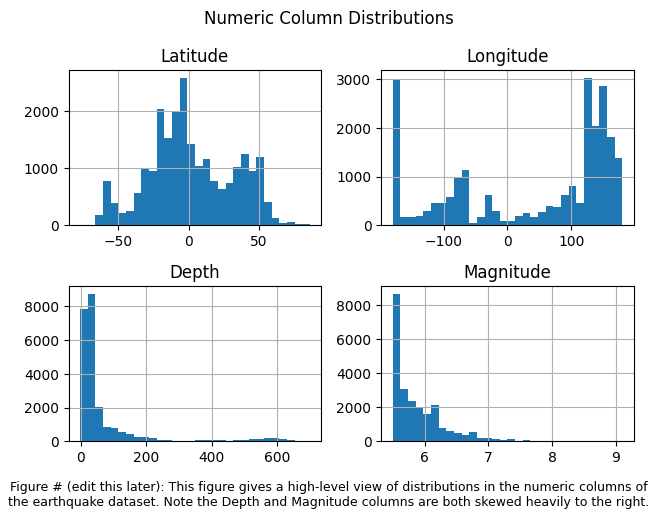

In [8]:
# EDA

# histogram of all numeric columns

num_cols = ["Latitude",
            "Longitude",
            "Depth",
            "Magnitude"]
numeric_earthquake_df = earthquakes_df_cleaned[num_cols]
numeric_earthquake_df.hist(
   column=num_cols,
   bins=30,
)
dist_figtext = (
    "Figure # (edit this later): This figure gives a high-level view of distributions "
    "in the numeric columns of the earthquake dataset. Note the Depth and "
    "Magnitude columns are both skewed heavily to the right."
)
plt.figtext(0.5, 
            -0.05, 
            dist_figtext, 
            ha="center",
            wrap=True,
            fontsize=9)
plt.suptitle("Numeric Column Distributions")
plt.tight_layout()



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


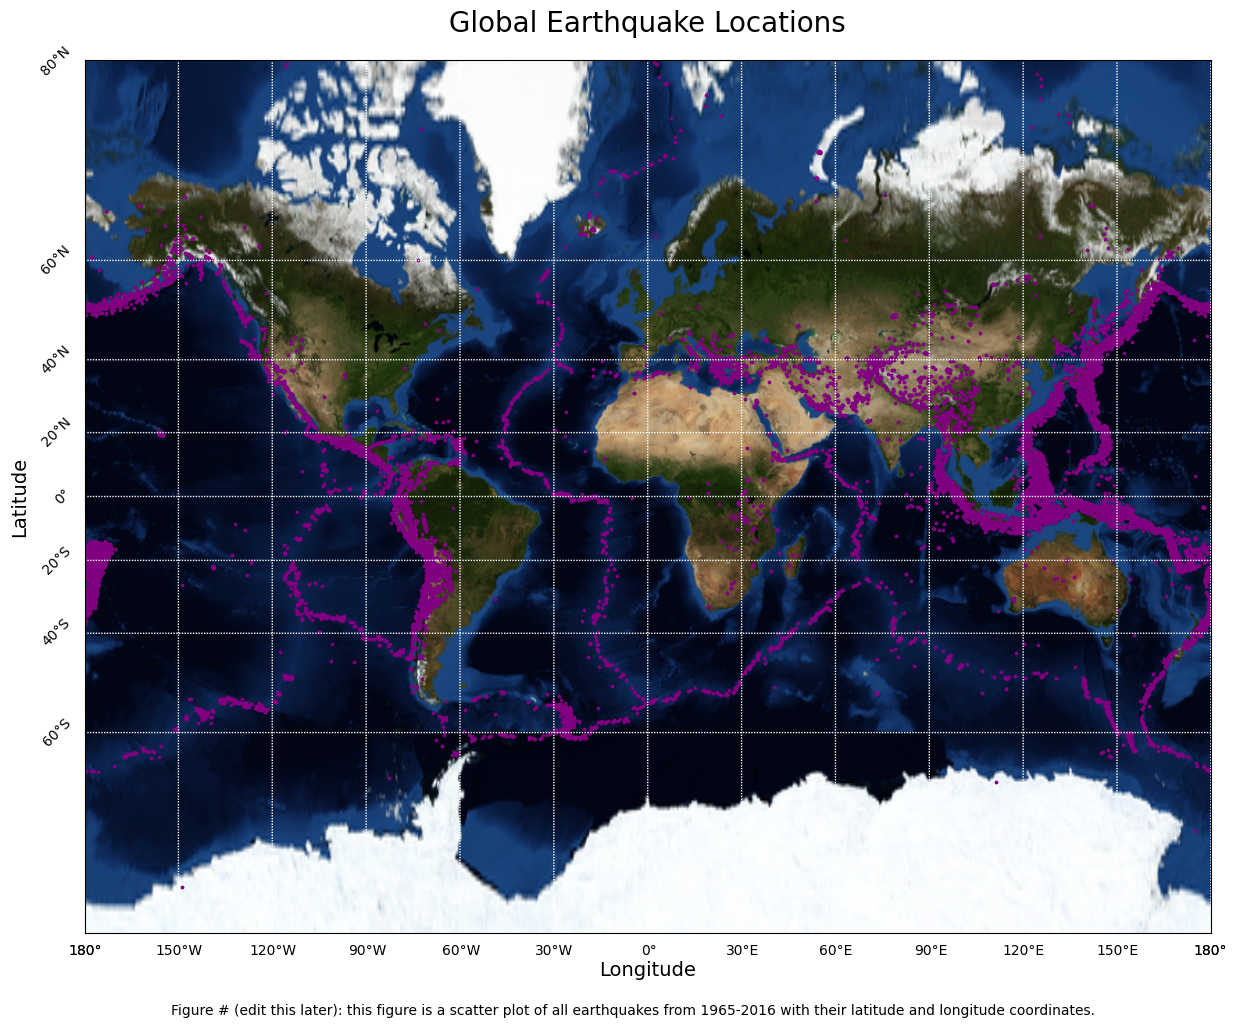

In [9]:
fig, ax = plt.subplots(figsize=(14, 10))

map = Basemap(
    projection="merc",
    llcrnrlat=-80,
    urcrnrlat=80,
    llcrnrlon=-180,
    urcrnrlon=180,
    lat_ts=20,
    resolution="c"
)
map.bluemarble(scale=0.2)
x, y = map(earthquakes_df_cleaned["Longitude"], earthquakes_df_cleaned["Latitude"])
map.scatter(x, y, 3, marker="o", color="purple")

parallels = map.drawparallels(
    np.arange(-60, 81, 20),
    labels=[1, 0, 0, 0],
    fontsize=10,
    color="white"
)
map.drawmeridians(
    np.arange(-180, 181, 30),
    labels=[0, 0, 0, 1],
    fontsize=10,
    color="white"
)

for _, (_, texts) in parallels.items():
    for text in texts:
        text.set_rotation(45)

ax.set_xlabel("Longitude", fontsize=14, labelpad=20)
ax.set_ylabel("Latitude", fontsize=14, labelpad=40)
ax.set_title("Global Earthquake Locations", fontsize=20, pad=20)
map_figtext = (
    "Figure # (edit this later): this figure is a scatter plot of all earthquakes "
    "from 1965-2016 with their latitude and longitude coordinates."
)
plt.figtext(0.5, 
            -0.02, 
            map_figtext, 
            wrap=True,
            ha="center")
plt.tight_layout()
plt.show()

Text(0.5, -0.02, 'Figure # (edit this later): This scatterplot depicts all earthquakes in the dataset and their related depths. A blue, horizontal, dashed line indicates earthquakes with a magnitude of 8.0 or greater.')

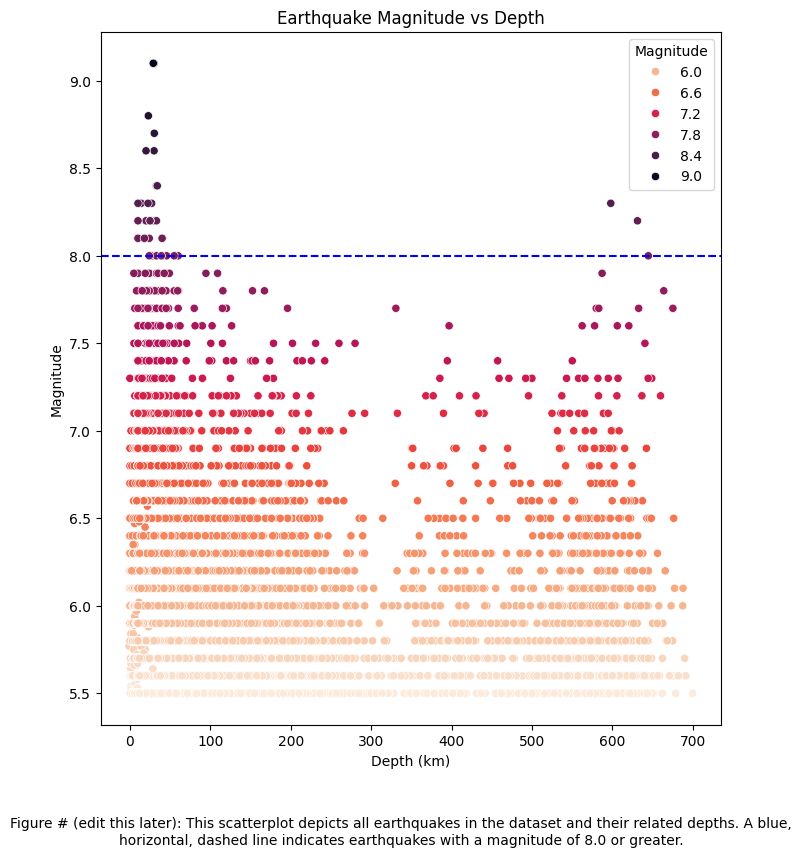

In [10]:
plt.figure(figsize=(8, 9))

sns.scatterplot(
    earthquakes_df_cleaned,
    x="Depth",
    y="Magnitude",
    hue="Magnitude",
    palette="rocket_r"
)
plt.axhline(y=8, color="blue", linestyle="--")
plt.title("Earthquake Magnitude vs Depth")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")

depth_scat_text = (
    "Figure # (edit this later): This scatterplot depicts all earthquakes in the "
    "dataset and their related depths. A blue, horizontal, dashed line indicates "
    "earthquakes with a magnitude of 8.0 or greater."
)
plt.figtext(0.5,
            -0.02,
            depth_scat_text,
            ha="center",
            wrap=True)

In [11]:
large_quakes_mask = earthquakes_df_cleaned["Magnitude Category"] == "8+"
large_quakes_df = earthquakes_df_cleaned[large_quakes_mask]
large_quakes_df

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=large_quakes_df,
    x="Depth"
)
x_ticks = np.arange(0, 700, 200)
plt.xticks(x_ticks)
plt.title("Depth Distribution for 8+ Magnitude Earthquakes")
plt.xlabel("Depth (km)")
boxplot_figtext = (
    "Figure # (edit this later): "
)
plt.figtext(0.5, -0.02, 'Figure #(edit later): This is a caption', wrap=True, ha="center", fontsize=10)
plt.tight_layout()

KeyError: 'Magnitude Category'

In [ ]:
earthquakes_df_cleaned["Magnitude Category"] = pd.cut(
    earthquakes_df_cleaned["Magnitude"],
    bins=[5.5, 6, 6.9, 7.9, 10],
    labels=["5.5-6", "6.1-6.9", "7-7.9", "8+"]
)

count_per_year_df = (
    earthquakes_df_cleaned
    .groupby(
        [earthquakes_df_cleaned["Date"].dt.year,
        "Magnitude Category"]
    )
    .size()
    .reset_index(name="count")
)
count_per_year_df.columns = ["Year", "Magnitude Category", "Count"]

mags_5_6_mask = count_per_year_df["Magnitude Category"].isin(["5.5-6", "6.1-6.9"])
mags_5_6_df = count_per_year_df[mags_5_6_mask]

mag_mask = count_per_year_df["Magnitude Category"].isin(["7-7.9", "8+"])
extreme_earthquakes_per_year_df = count_per_year_df[mag_mask]

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 14)
)

# Plot 1
sns.lineplot(
    mags_5_6_df,
    x="Year",
    y="Count",
    hue="Magnitude Category",
    ax=ax1
)
year_ticks = np.arange(1965, 2017, 2)
ax1.set_xticks(year_ticks)
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Moderate to Strong Earthquakes per Year", fontsize=16)
ax1.set_ylabel("Count", fontsize=12, labelpad=10)
ax1.set_xlabel("Year", fontsize=12, labelpad=10)

handles, labels = ax1.get_legend_handles_labels()
ax1.legend_.remove()

# Plot 2
sns.lineplot(
    extreme_earthquakes_per_year_df,
    x="Year",
    y="Count",
    hue="Magnitude Category",
    ax=ax2
)

ax2.set_xticks(year_ticks)
ax2.tick_params(axis="x", rotation=45)
ax2.set_title("Major Earthquakes per Year", fontsize=16)
ax2.set_ylabel("Count", fontsize=12, labelpad=10)
ax2.set_xlabel("Year", fontsize=12, labelpad=10)
ax2.legend_.remove()

fig.legend(
    handles,
    labels,
    title="Magnitude Category",
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 0.95)
)
plt.subplots_adjust(hspace=0.3)